In [7]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

run = 'a_20260401_083245'
# run = None  # Set to None to auto-detect the latest CSV file in results/

# Set to a CSV path string to force a specific file, e.g. '../results/my_file.csv'.
csv_file = f'../results/{run}/summary_{run}.csv' if run else None

results_candidates = [Path('results'), Path('../results')]
results_dir = next((p for p in results_candidates if p.exists() and p.is_dir()), None)
if results_dir is None:
    searched = [str(p.resolve()) for p in results_candidates]
    raise FileNotFoundError(f"Results folder not found. Searched: {searched}")

if csv_file is None:
    csv_candidates = sorted(results_dir.rglob('*.csv'))
    if not csv_candidates:
        raise FileNotFoundError(f"No .csv files found inside {results_dir.resolve()}")
    csv_file = str(csv_candidates[0])

print(f"Using CSV file: {csv_file}")
df = pd.read_csv(csv_file)

required_columns = ['instance', 'algorithm', 'objective_mean', 'exec_time_mean']
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

best_objectives_candidates = [
    Path('best_solutions') / 'best_objectives.csv',
    Path('../best_solutions') / 'best_objectives.csv',
]
best_objectives_path = next((p for p in best_objectives_candidates if p.exists()), None)
if best_objectives_path is None:
    searched = [str(p.resolve()) for p in best_objectives_candidates]
    raise FileNotFoundError(f"Best objectives file not found. Searched: {searched}")

best_df = pd.read_csv(best_objectives_path)
if 'instance' not in best_df.columns or 'best_objective' not in best_df.columns:
    raise ValueError("best_objectives.csv must contain columns: instance, best_objective")

if 'dataset' in df.columns and 'dataset' in best_df.columns:
    merge_columns = ['dataset', 'instance']
else:
    merge_columns = ['instance']

df = df.merge(best_df[merge_columns + ['best_objective']], on=merge_columns, how='left')
ordered_columns = [col for col in df.columns if col != 'best_objective'] + ['best_objective']
df = df[ordered_columns]

df.head()

Using CSV file: ../results/a_20260401_083245/summary_a_20260401_083245.csv


,dataset,algorithm,instance,total_runs,feasible_runs,timed_out_runs,objective_mean,objective_median,objective_mode,objective_min,...,aisles_variance,aisles_std_dev,exec_time_mean,exec_time_median,exec_time_mode,exec_time_min,exec_time_max,exec_time_variance,exec_time_std_dev,best_objective
0,a,aisle_cluster_expansion,instance_0001.txt,1,1,0,15.00,15.00,15.00,15.00,...,0.0,0.0,0.114049,0.114049,0.114049,0.114049,0.114049,0.0,0.0,15.0
1,a,aisle_cluster_expansion,instance_0002.txt,1,1,0,2.00,2.00,2.00,2.00,...,0.0,0.0,0.000514,0.000514,0.000514,0.000514,0.000514,0.0,0.0,2.0
2,a,aisle_cluster_expansion,instance_0003.txt,1,1,0,8.75,8.75,8.75,8.75,...,0.0,0.0,0.248051,0.248051,0.248051,0.248051,0.248051,0.0,0.0,12.0
3,a,aisle_cluster_expansion,instance_0004.txt,1,1,0,3.50,3.50,3.50,3.50,...,0.0,0.0,0.016616,0.016616,0.016616,0.016616,0.016616,0.0,0.0,3.5
4,a,aisle_cluster_expansion,instance_0006.txt,1,1,0,691.00,691.00,691.00,691.00,...,0.0,0.0,1.708238,1.708238,1.708238,1.708238,1.708238,0.0,0.0,691.0


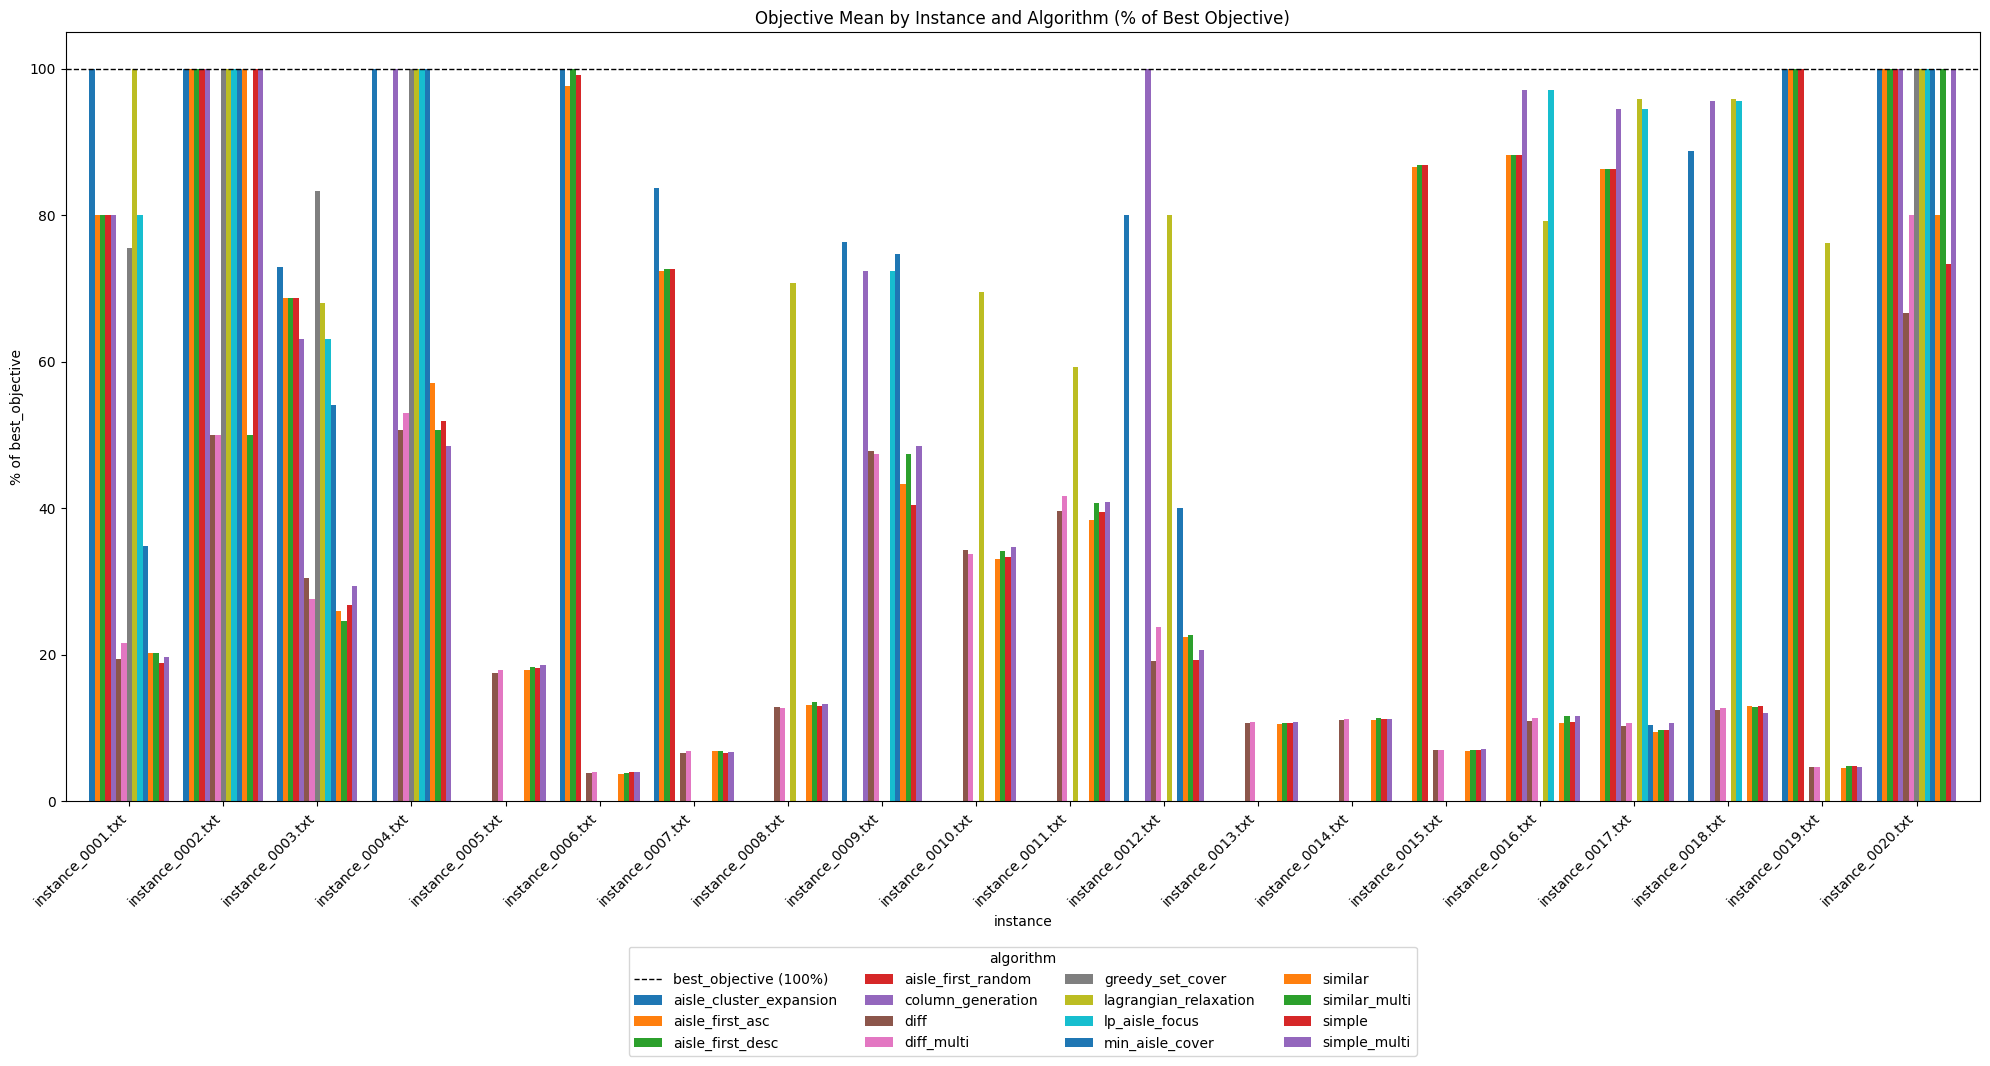

In [17]:
objective_plot = (
    df.pivot_table(
        index='instance',
        columns='algorithm',
        values='objective_mean',
        aggfunc='mean'
    )
    .sort_index()
    .fillna(0)
)

best_objective_by_instance = (
    df[['instance', 'best_objective']]
    .drop_duplicates(subset='instance')
    .set_index('instance')['best_objective']
)

objective_pct_plot = objective_plot.div(best_objective_by_instance, axis=0) * 100
objective_pct_plot = objective_pct_plot.replace([float('inf'), -float('inf')], 0).fillna(0)

ax = objective_pct_plot.plot(kind='bar', figsize=(20, 12), width=0.85)
ax.axhline(100, color='black', linestyle='--', linewidth=1, label='best_objective (100%)')
ax.set_xlabel('instance')
ax.set_ylabel('% of best_objective')
ax.set_title('Objective Mean by Instance and Algorithm (% of Best Objective)')
ax.legend(title='algorithm', loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

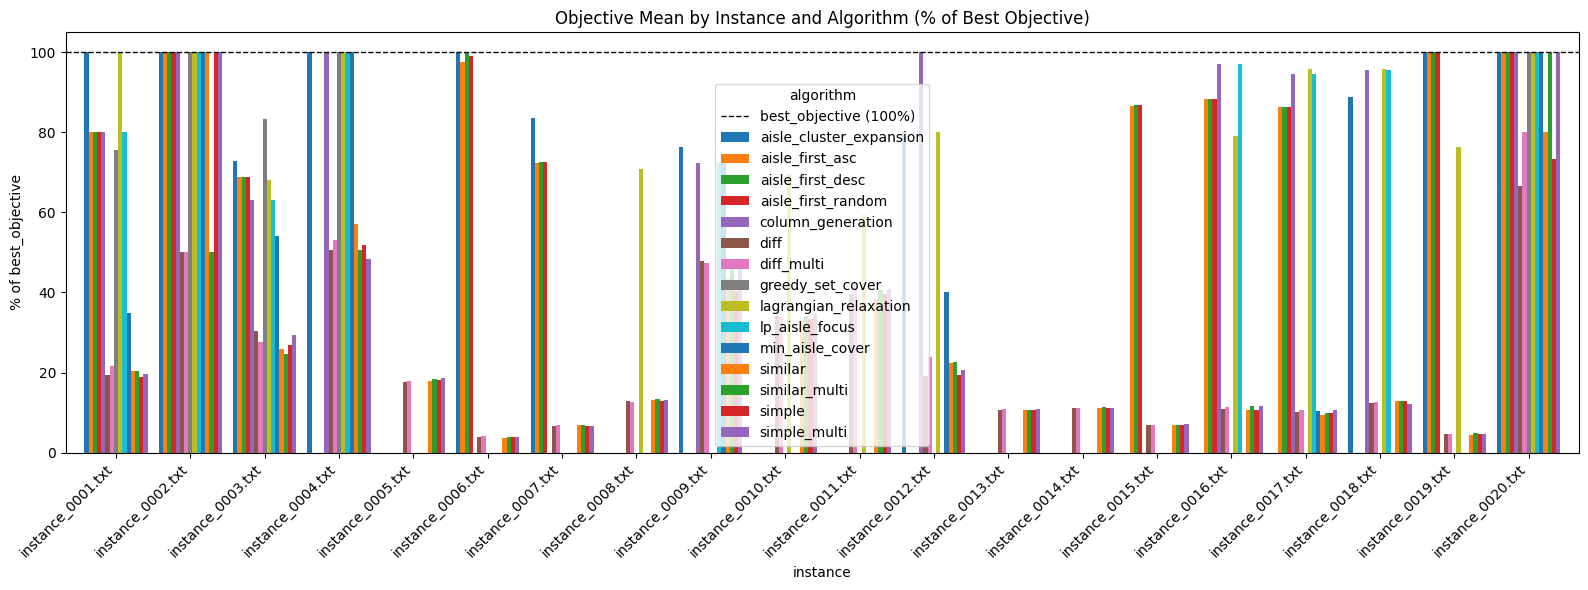

In [ ]:
objective_plot = (
    df.pivot_table(
        index="instance", columns="algorithm", values="objective_mean", aggfunc="mean"
    )
    .sort_index()
    .fillna(0)
)

best_objective_by_instance = (
    df[["instance", "best_objective"]]
    .drop_duplicates(subset="instance")
    .set_index("instance")["best_objective"]
)

objective_pct_plot = objective_plot.div(best_objective_by_instance, axis=0) * 100
objective_pct_plot = objective_pct_plot.replace(
    [float("inf"), -float("inf")], 0
).fillna(0)

ax = objective_pct_plot.plot(kind="bar", figsize=(16, 6), width=0.85)
ax.axhline(
    100, color="black", linestyle="--", linewidth=1, label="best_objective (100%)"
)
ax.set_xlabel("instance")
ax.set_ylabel("% of best_objective")
ax.set_title("Objective Mean by Instance and Algorithm (% of Best Objective)")
ax.legend(title="algorithm", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

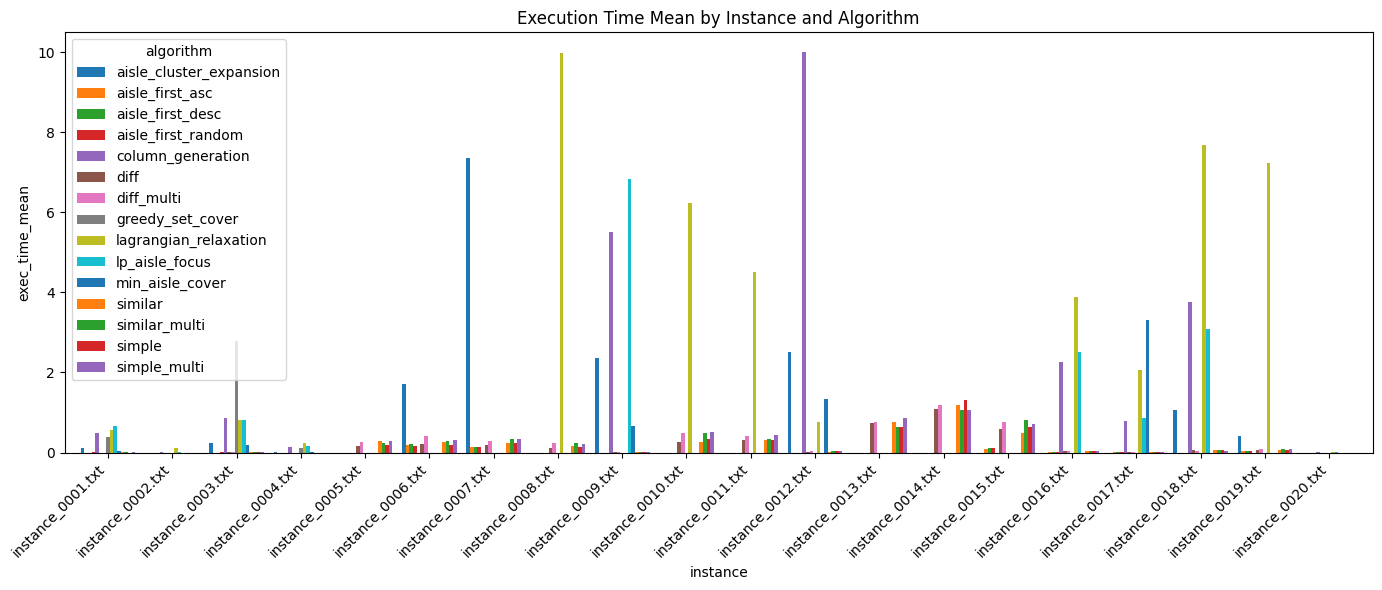

In [ ]:
exec_time_plot = (
    df.pivot_table(
        index='instance',
        columns='algorithm',
        values='exec_time_mean',
        aggfunc='mean'
    )
    .sort_index()
    .fillna(0)
)

ax = exec_time_plot.plot(kind='bar', figsize=(14, 6), width=0.85)
ax.set_xlabel('instance')
ax.set_ylabel('exec_time_mean')
ax.set_title('Execution Time Mean by Instance and Algorithm')
ax.legend(title='algorithm', loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=4)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [11]:
ranking_dataset_param = None  # e.g., 'a', 'b', 'x' or None for all datasets

ranking_base = df[["instance", "algorithm", "objective_mean", "exec_time_mean"]].copy()
if ranking_dataset_param is not None and "dataset" in df.columns:
    ranking_base = df[df["dataset"] == ranking_dataset_param][
        ["instance", "algorithm", "objective_mean", "exec_time_mean"]
    ].copy()

if ranking_base.empty:
    raise ValueError(f"No rows found for dataset={ranking_dataset_param!r}")


def build_final_ranking(base_df: pd.DataFrame, metric_column: str, ascending: bool) -> pd.DataFrame:
    metric_df = base_df.dropna(subset=[metric_column]).copy()
    if metric_df.empty:
        raise ValueError(f"No non-null values found for metric {metric_column!r}.")

    metric_df["N"] = metric_df.groupby("instance")["algorithm"].transform("nunique")
    metric_df["rank_class"] = metric_df.groupby("instance")[metric_column].rank(
        method="min", ascending=ascending
    ).astype(int)
    metric_df["score"] = metric_df["N"] - metric_df["rank_class"]

    final_ranking = (
        metric_df.groupby("algorithm", as_index=False)["score"]
        .agg(total_score="sum", average_score="mean", instances_count="count")
        .sort_values(["total_score", "average_score", "algorithm"], ascending=[False, False, True])
        .reset_index(drop=True)
    )
    final_ranking["final_rank"] = final_ranking["total_score"].rank(
        method="min", ascending=False
    ).astype(int)

    return final_ranking[
        ["final_rank", "algorithm", "total_score", "average_score", "instances_count"]
    ]


objective_ranking = build_final_ranking(
    ranking_base, metric_column="objective_mean", ascending=False
)
exec_time_ranking = build_final_ranking(
    ranking_base, metric_column="exec_time_mean", ascending=True
)

print(f"Dataset filter for ranking: {ranking_dataset_param!r}")
print("\nOBJECTIVE_MEAN - FINAL RANKING")
display(objective_ranking)
print("\nEXEC_TIME_MEAN - FINAL RANKING")
display(exec_time_ranking)

Dataset filter for ranking: None

OBJECTIVE_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,lagrangian_relaxation,121,9.307692,13
1,2,aisle_cluster_expansion,117,10.636364,11
2,3,aisle_first_desc,105,10.500000,10
3,3,column_generation,105,10.500000,10
4,5,aisle_first_random,103,10.300000,10
5,6,aisle_first_asc,98,9.800000,10
6,7,lp_aisle_focus,96,10.666667,9
7,8,simple_multi,89,4.450000,20
8,9,similar_multi,77,3.850000,20
9,10,min_aisle_cover,69,8.625000,8



EXEC_TIME_MEAN - FINAL RANKING


,final_rank,algorithm,total_score,average_score,instances_count
0,1,diff,142,7.100000,20
1,2,simple,133,6.650000,20
2,3,similar,115,5.750000,20
3,4,simple_multi,98,4.900000,20
4,5,diff_multi,97,4.850000,20
5,6,similar_multi,96,4.800000,20
6,7,aisle_first_asc,92,9.200000,10
7,8,aisle_first_desc,85,8.500000,10
8,9,aisle_first_random,76,7.600000,10
9,10,min_aisle_cover,34,4.250000,8
